# 📊 Laptop Price Prediction — Exploratory Data Analysis

**Notebook:** `01_eda.ipynb`  
**Dataset:** `laptop data/laptop_data.csv`  
**Objective:** Understand the data, distributions, and price drivers before modelling.

---
> **Scope:** EDA only. No model training. No target-based feature engineering.

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from src.preprocessing import load_and_clean
from src.features import engineer_features, ENGINEERED_FEATURES, TARGET

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "#0f1117",
    "axes.facecolor": "#1a1d27",
    "axes.edgecolor": "#3a3f5c",
    "axes.labelcolor": "#c8cce0",
    "axes.titlesize": 13,
    "axes.titlecolor": "#e8eaf6",
    "axes.titleweight": "bold",
    "xtick.color": "#9199c2",
    "ytick.color": "#9199c2",
    "text.color": "#c8cce0",
    "grid.color": "#2c3057",
    "grid.linewidth": 0.6,
    "legend.facecolor": "#1a1d27",
    "legend.edgecolor": "#3a3f5c",
    "legend.labelcolor": "#c8cce0",
    "font.family": "DejaVu Sans",
})

PALETTE  = "plasma"
ACCENT   = "#7c83fd"
HIGHLIGHT= "#fd7c83"

def fmt_inr(x, pos=None):
    """Format price axis ticks as ₹K."""
    return f"₹{x/1000:.0f}K"

print("Libraries loaded.")

Libraries loaded.


---
## 1. Load & Prepare Data

In [2]:
df_raw   = load_and_clean("../laptop data/laptop_data.csv")
df       = engineer_features(df_raw)

print(f"Dataset shape : {df.shape}")
print(f"Rows          : {df.shape[0]:,}")
print(f"Columns       : {df.shape[1]}  ({len(ENGINEERED_FEATURES)} engineered + {df.shape[1]-len(ENGINEERED_FEATURES)} original)")
df.head(3)

Dataset shape : (1303, 29)
Rows          : 1,303
Columns       : 29  (18 engineered + 11 original)


,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,...,cpu_family,cpu_speed_ghz,gpu_brand,gpu_family,ssd_gb,hdd_gb,flash_storage_gb,hybrid_gb,total_storage_gb,primary_storage_type
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,...,Core i5,2.3,Intel,Intel Iris Plus,128.0,0.0,0.0,0.0,128.0,SSD
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,...,Core i5,1.8,Intel,Intel HD,0.0,0.0,128.0,0.0,128.0,Flash
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,...,Core i5,2.5,Intel,Intel HD,256.0,0.0,0.0,0.0,256.0,SSD


---
## 2. Dataset Overview

In [3]:
# Quick summary table
summary = pd.DataFrame({
    "dtype"      : df.dtypes,
    "non_null"   : df.notnull().sum(),
    "null_count" : df.isnull().sum(),
    "n_unique"   : df.nunique(),
    "sample"     : [str(df[c].iloc[0])[:50] for c in df.columns],
})
print(summary.to_string())

                        dtype  non_null  null_count  n_unique                              sample
Company                   str      1303           0        19                               Apple
TypeName                  str      1303           0         6                           Ultrabook
Inches                float64      1303           0        18                                13.3
ScreenResolution          str      1303           0        40  IPS Panel Retina Display 2560x1600
Cpu                       str      1303           0       118                Intel Core i5 2.3GHz
Ram                       str      1303           0         9                                 8GB
Memory                    str      1303           0        39                           128GB SSD
Gpu                       str      1303           0       106        Intel Iris Plus Graphics 640
OpSys                     str      1303           0         7                               macOS
Weight              

---
## 3. Target Variable — Price Distribution

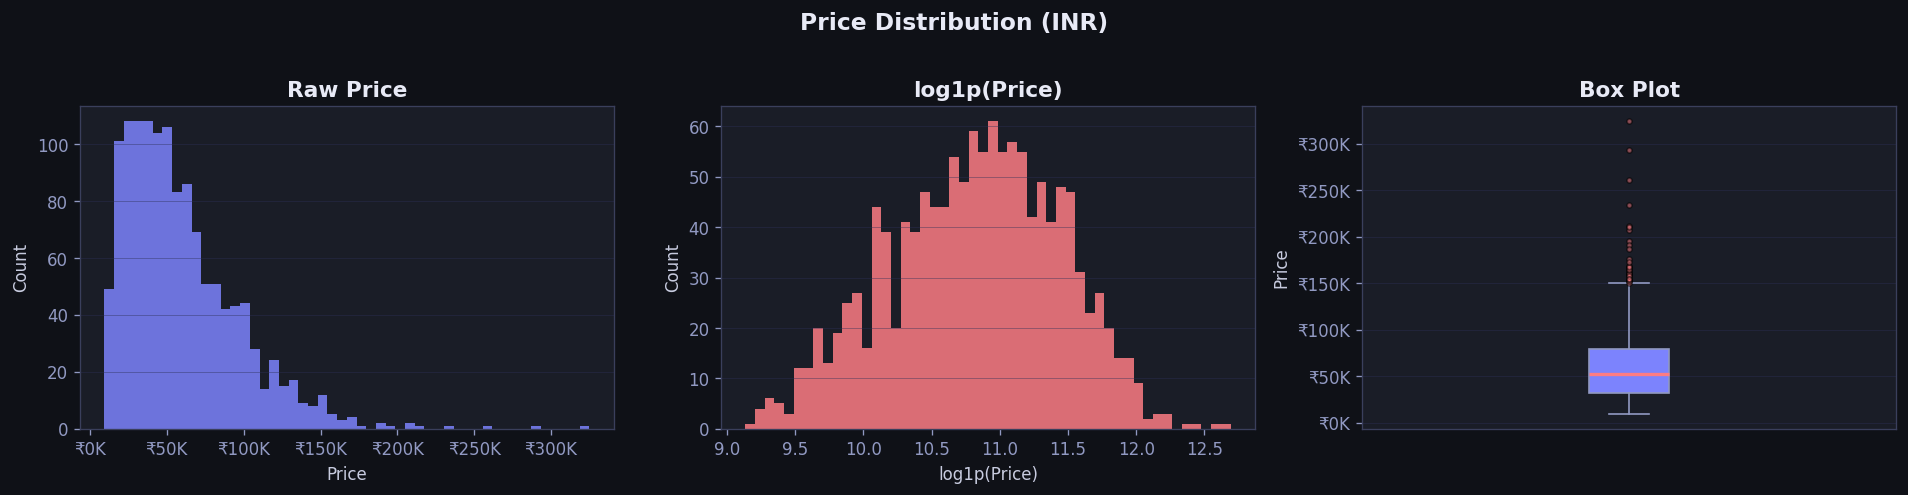

─────────────────────────────────────────────
  Mean    : ₹    59,870
  Median  : ₹    52,055
  Std Dev : ₹    37,243
  Min     : ₹     9,271
  Max     : ₹   324,955
  Skew    :      1.521
  IQR outliers : 29
─────────────────────────────────────────────


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Price Distribution (INR)", y=1.02, fontsize=14, color="#e8eaf6", fontweight="bold")

# Raw price histogram
ax = axes[0]
ax.hist(df[TARGET], bins=50, color=ACCENT, edgecolor="none", alpha=0.85)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_inr))
ax.set_title("Raw Price")
ax.set_xlabel("Price")
ax.set_ylabel("Count")
ax.grid(axis="y", alpha=0.4)

# Log-transformed
ax = axes[1]
ax.hist(np.log1p(df[TARGET]), bins=50, color=HIGHLIGHT, edgecolor="none", alpha=0.85)
ax.set_title("log1p(Price)")
ax.set_xlabel("log1p(Price)")
ax.set_ylabel("Count")
ax.grid(axis="y", alpha=0.4)

# Box plot
ax = axes[2]
ax.boxplot(df[TARGET], vert=True, patch_artist=True,
           boxprops=dict(facecolor=ACCENT, color="#9199c2"),
           medianprops=dict(color=HIGHLIGHT, linewidth=2),
           whiskerprops=dict(color="#9199c2"),
           capprops=dict(color="#9199c2"),
           flierprops=dict(marker="o", markerfacecolor=HIGHLIGHT, markersize=3, alpha=0.5))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_inr))
ax.set_title("Box Plot")
ax.set_ylabel("Price")
ax.set_xticks([])
ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.show()

# Stats
price_stats = df[TARGET].describe()
q1, q3 = price_stats["25%"], price_stats["75%"]
iqr    = q3 - q1
n_out  = ((df[TARGET] < q1-1.5*iqr) | (df[TARGET] > q3+1.5*iqr)).sum()
print("─" * 45)
print(f"  Mean    : ₹{price_stats['mean']:>10,.0f}")
print(f"  Median  : ₹{price_stats['50%']:>10,.0f}")
print(f"  Std Dev : ₹{price_stats['std']:>10,.0f}")
print(f"  Min     : ₹{price_stats['min']:>10,.0f}")
print(f"  Max     : ₹{price_stats['max']:>10,.0f}")
print(f"  Skew    : {df[TARGET].skew():>10.3f}")
print(f"  IQR outliers : {n_out}")
print("─" * 45)

**Observations:**
- Price is strongly **right-skewed** (skew ≈ 1.52). A small number of premium/workstation laptops pull the mean above the median by ~₹8K.
- The `log1p` transform yields a near-normal distribution — **recommended for regression modelling**.
- 29 IQR outliers exist but they are legitimate (high-end machines), not data errors.

---
## 4. Categorical Distributions

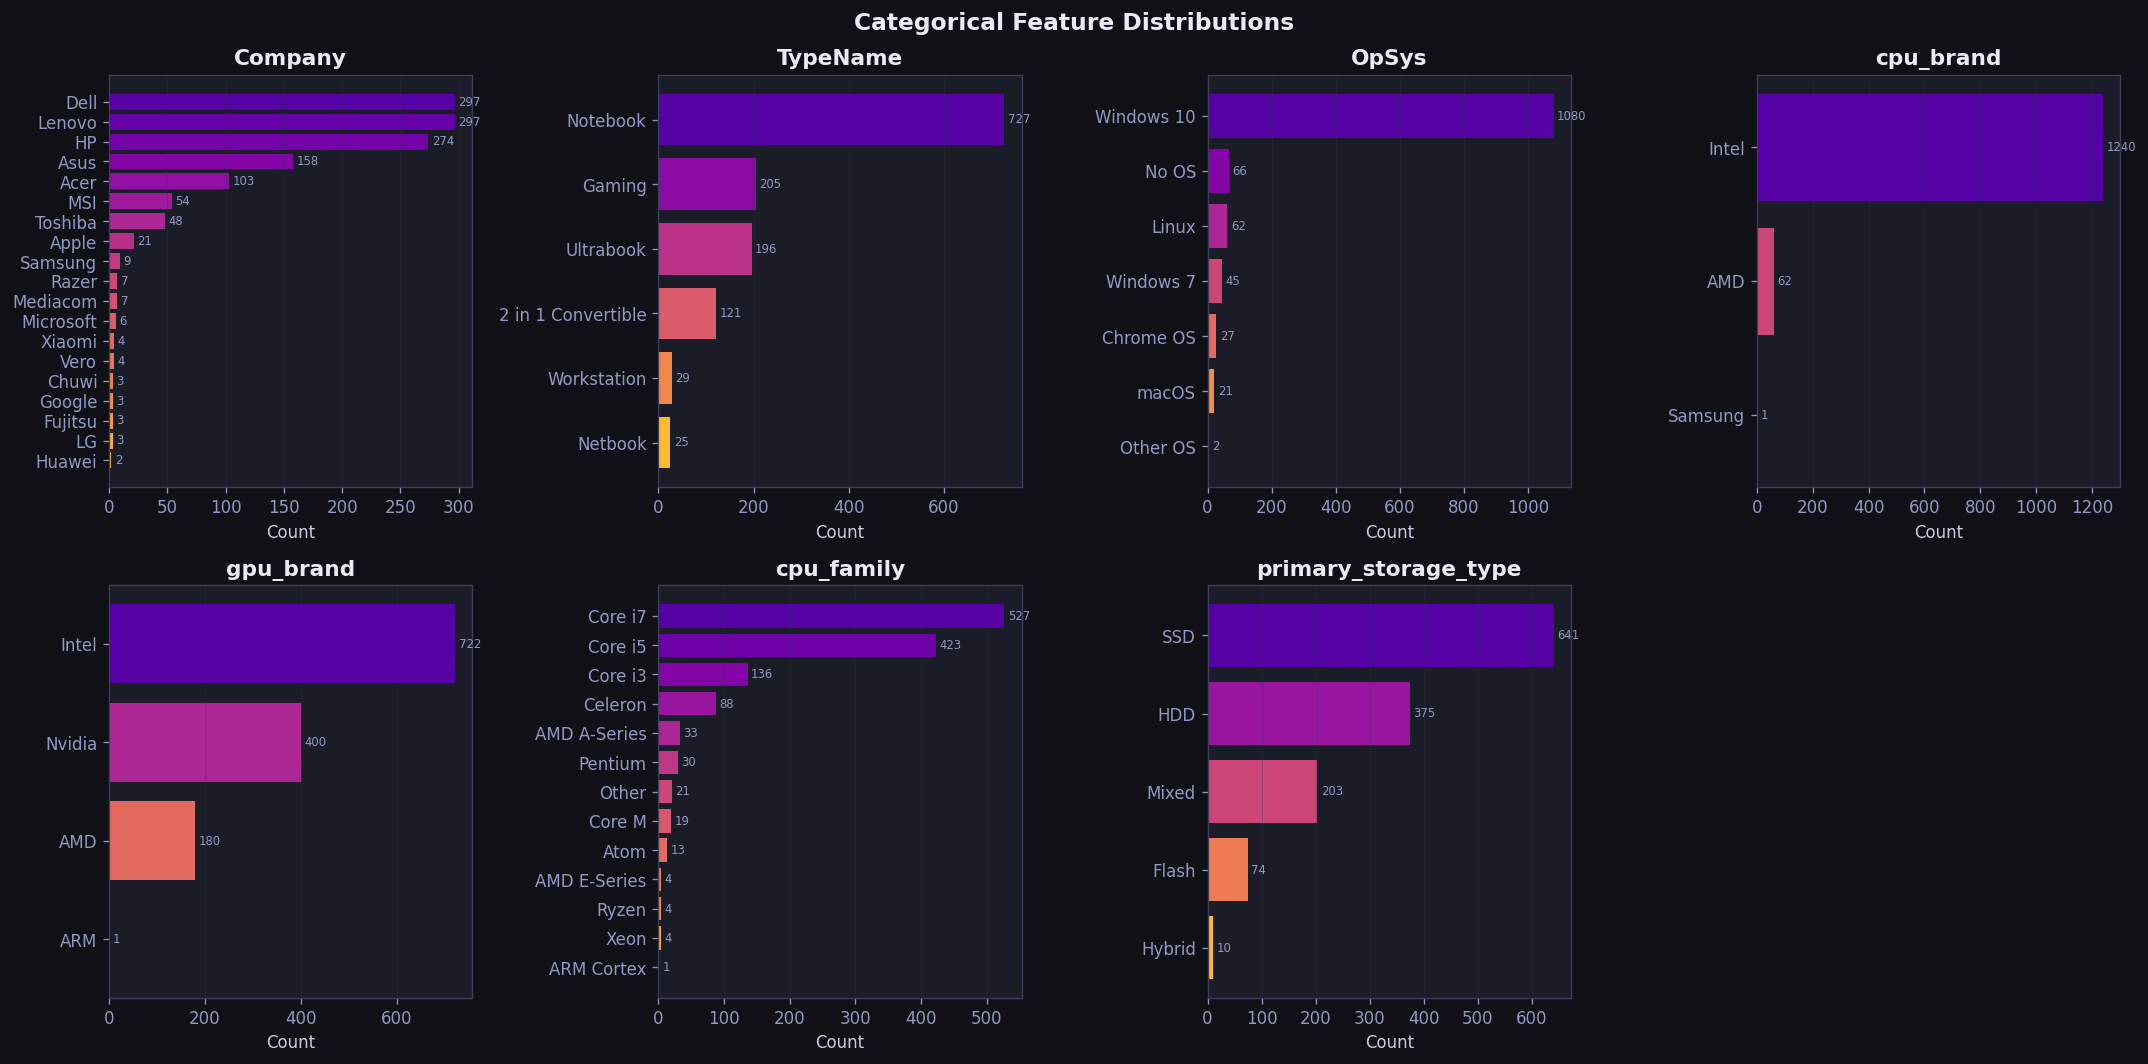

In [5]:
cat_cols = ["Company", "TypeName", "OpSys", "cpu_brand", "gpu_brand",
            "cpu_family", "primary_storage_type"]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle("Categorical Feature Distributions", fontsize=14, color="#e8eaf6", fontweight="bold")
axes_flat = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes_flat[i]
    vc = df[col].value_counts()
    colors = plt.cm.plasma(np.linspace(0.15, 0.85, len(vc)))
    bars = ax.barh(vc.index[::-1], vc.values[::-1], color=colors[::-1], edgecolor="none")
    ax.set_title(col)
    ax.set_xlabel("Count")
    ax.grid(axis="x", alpha=0.3)
    # value labels
    for bar, val in zip(bars, vc.values[::-1]):
        ax.text(val + vc.max()*0.01, bar.get_y() + bar.get_height()/2,
                str(val), va="center", fontsize=7, color="#9199c2")

# Hide unused subplot
axes_flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

**Observations:**
- **Company:** Dell & Lenovo dominate equally (297 each), followed by HP (274). Premium brands (Apple, Razer, Microsoft) are rare (<25 rows each).
- **TypeName:** Notebooks are the majority (727), Gaming & Ultrabooks are sizable (~200 each). Netbooks (25) and Workstations (29) are sparse.
- **OpSys:** Windows 10 overwhelms (~83%). No OS (66) and Linux (62) are notable. Android (2 rows) are now grouped under 'Other OS'.
- **CPU Brand:** Intel (95%) vastly dominates. AMD ~5%. Samsung/ARM Cortex = 1 row.
- **GPU Brand:** Intel (integrated) leads at ~55%, Nvidia at ~31%, AMD ~14%.
- **Storage:** SSD-primary is the most common (641), HDD second (375). Mixed configs (203) are significant.

---
## 5. Price by Company

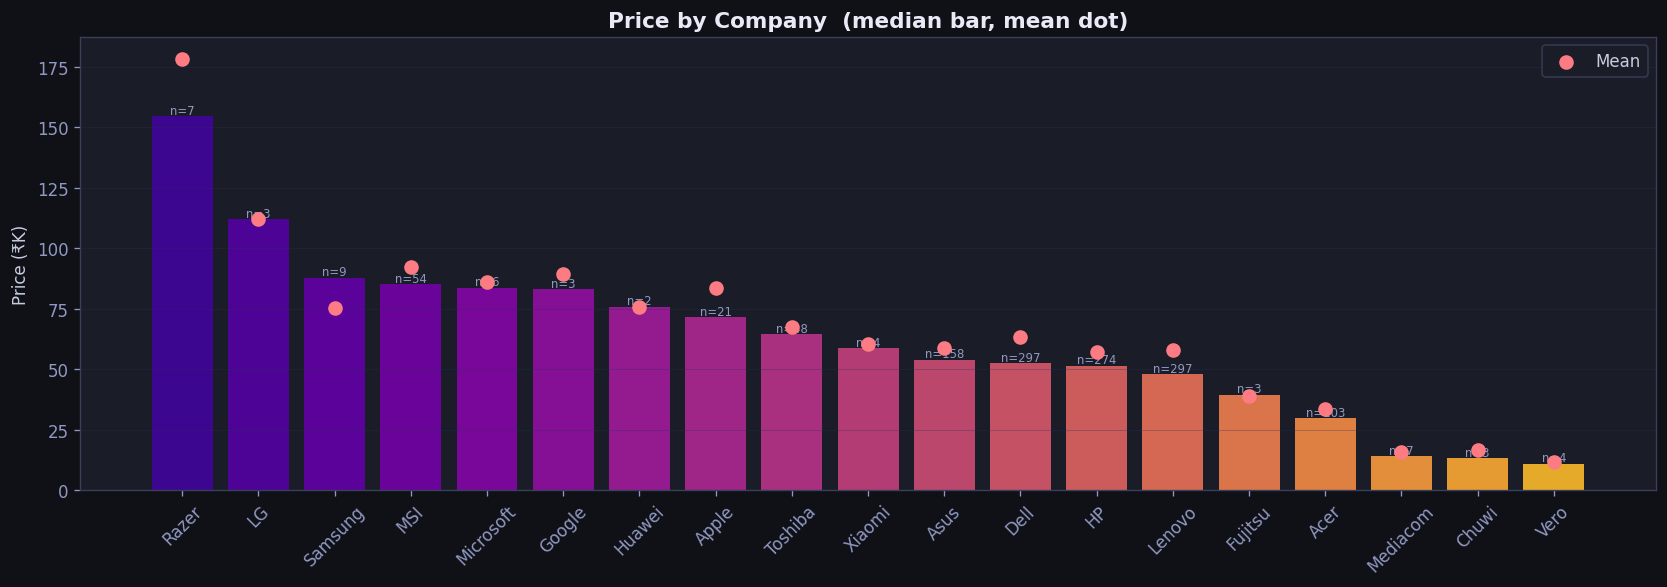

              Median ₹         Mean ₹    N
Company                                   
Razer      154458.7200  178282.491429    7
LG         111834.7200  111834.720000    3
Samsung     87858.7200   75308.320000    9
MSI         85194.7200   92116.226133   54
Microsoft   83622.9600   85903.788000    6
Google      83063.5200   89386.080000    3
Huawei      75870.7200   75870.720000    2
Apple       71378.6832   83340.499886   21
Toshiba     64548.7200   67549.050000   48
Xiaomi      58578.6960   60390.882000    4
Asus        53946.0000   58830.143878  158
Dell        52480.8000   63193.755782  297
HP          51495.1200   56891.044222  274
Lenovo      47898.7200   57882.563200  297
Fujitsu     39373.9200   38841.120000    3
Acer        29783.5200   33394.615969  103
Mediacom    14119.2000   15717.600000    7
Chuwi       13261.3920   16745.726400    3
Vero        11020.9680   11584.404000    4


In [6]:
company_stats = (df.groupby("Company")[TARGET]
                   .agg(["median", "mean", "count"])
                   .sort_values("median", ascending=False))

fig, ax = plt.subplots(figsize=(14, 5))
colors = plt.cm.plasma(np.linspace(0.1, 0.85, len(company_stats)))

bars = ax.bar(company_stats.index, company_stats["median"] / 1000,
              color=colors, edgecolor="none", alpha=0.9)
ax.scatter(company_stats.index, company_stats["mean"] / 1000,
           color=HIGHLIGHT, zorder=5, s=60, label="Mean")

ax.set_title("Price by Company  (median bar, mean dot)")
ax.set_ylabel("Price (₹K)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=45)
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Count annotation
for bar, (_, row) in zip(bars, company_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"n={int(row['count'])}", ha="center", fontsize=7, color="#9199c2")

plt.tight_layout()
plt.show()

print(company_stats.rename(columns={"median": "Median ₹", "mean": "Mean ₹", "count": "N"}).to_string())

**Observations:**
- **Razer** commands the highest median price, followed by **LG**, **Microsoft**, and **Apple**.
- **Chuwi**, **Mediacom**, and **Vero** are the cheapest brands — budget/entry-level.
- **Dell, Lenovo, HP** span a wide price range — they serve all segments.
- Brand is a strong price signal, but low-count brands (n<10) add noise — consider grouping for modelling.

---
## 6. Price by Laptop Type

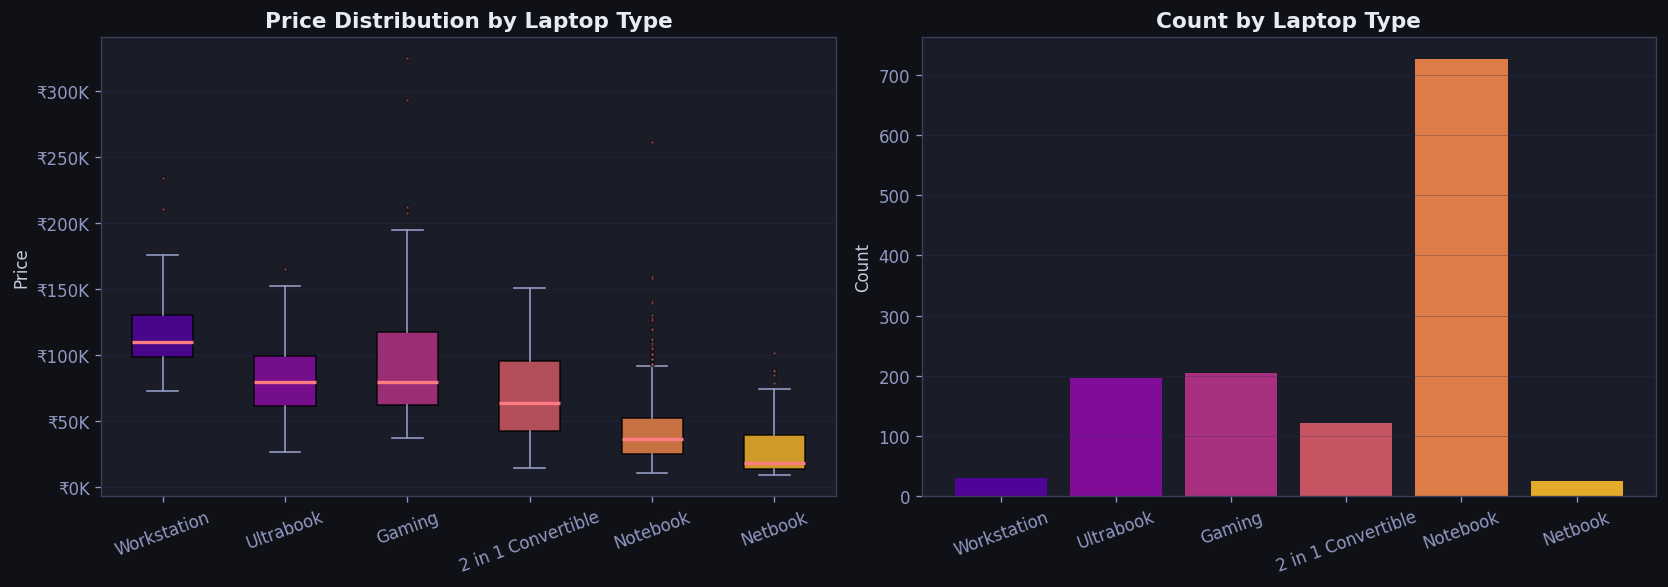

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = (df.groupby("TypeName")[TARGET].median()
           .sort_values(ascending=False).index)

# Box plot
ax = axes[0]
data_by_type = [df[df["TypeName"] == t][TARGET].values for t in order]
bp = ax.boxplot(data_by_type, labels=order, patch_artist=True, vert=True,
                medianprops=dict(color=HIGHLIGHT, linewidth=2),
                whiskerprops=dict(color="#9199c2"),
                capprops=dict(color="#9199c2"),
                flierprops=dict(marker="o", markerfacecolor=HIGHLIGHT, markersize=2, alpha=0.4))
colors = plt.cm.plasma(np.linspace(0.15, 0.85, len(order)))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.tick_params(axis="x", rotation=20)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_inr))
ax.set_title("Price Distribution by Laptop Type")
ax.set_ylabel("Price")
ax.grid(axis="y", alpha=0.3)

# Count bar
ax = axes[1]
counts = df["TypeName"].value_counts().reindex(order)
bars = ax.bar(order, counts.values,
              color=plt.cm.plasma(np.linspace(0.15, 0.85, len(order))),
              edgecolor="none", alpha=0.9)
ax.tick_params(axis="x", rotation=20)
ax.set_title("Count by Laptop Type")
ax.set_ylabel("Count")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Observations:**
- **Workstations** have the highest median and widest price range — they are niche but expensive.
- **Gaming** laptops cluster in the upper mid-range.
- **Ultrabooks** have a tighter, higher price range vs standard **Notebooks**.
- **Netbooks** are uniformly cheap, well-separated from other types.
- **2-in-1 Convertibles** are broadly distributed, overlapping with Ultrabooks and Notebooks.

---
## 7. Price vs RAM

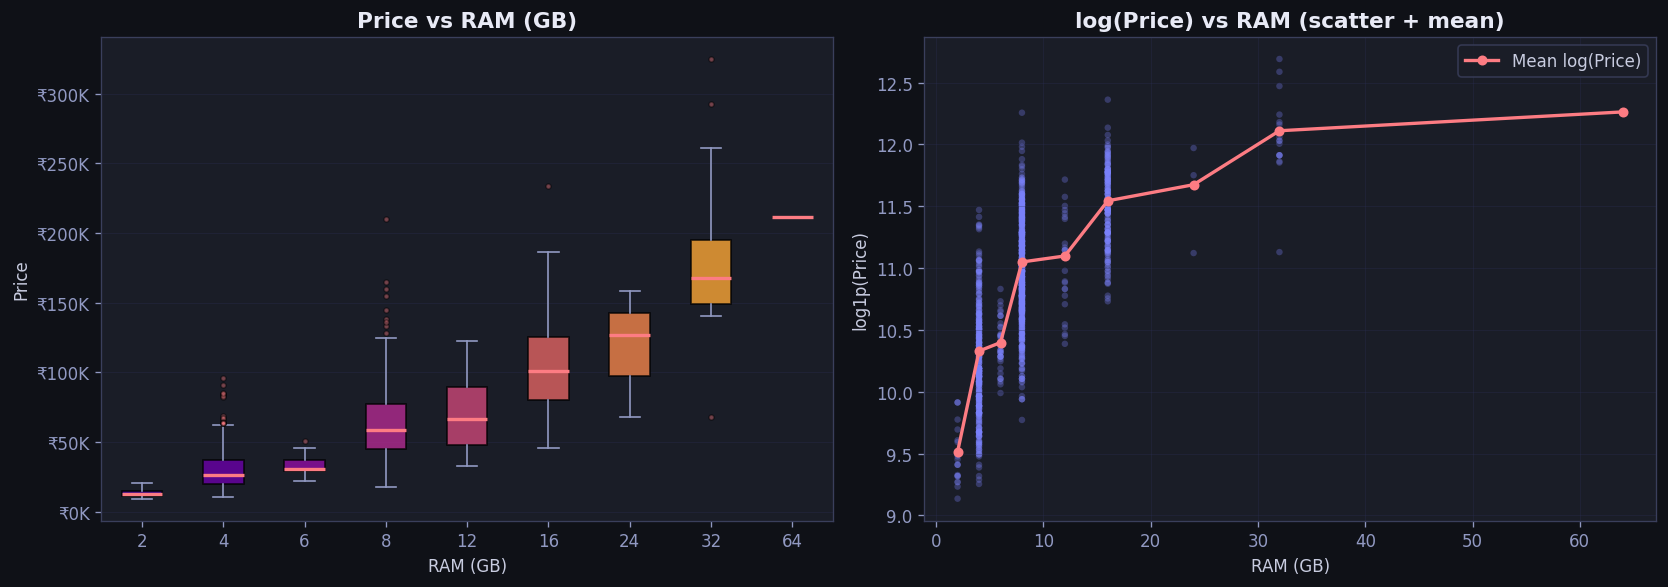

           Median ₹         Mean ₹    N
ram_gb                                 
2        12467.5200   13552.857818   22
4        26533.4400   30613.221734  375
6        30849.1200   32778.193873   41
8        58554.7200   62913.713455  619
12       66546.7200   66037.277952   25
16      100725.8400  103191.166872  200
24      126912.9600  117553.440000    3
32      167691.8736  181849.215812   17
64      211788.0000  211788.000000    1


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ram_order = sorted(df["ram_gb"].unique())

# Box plot
ax = axes[0]
data_by_ram = [df[df["ram_gb"] == r][TARGET].values for r in ram_order]
bp = ax.boxplot(data_by_ram, labels=ram_order, patch_artist=True,
                medianprops=dict(color=HIGHLIGHT, linewidth=2),
                whiskerprops=dict(color="#9199c2"),
                capprops=dict(color="#9199c2"),
                flierprops=dict(marker="o", markerfacecolor=HIGHLIGHT, markersize=3, alpha=0.4))
colors_ram = plt.cm.plasma(np.linspace(0.1, 0.9, len(ram_order)))
for patch, color in zip(bp["boxes"], colors_ram):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_inr))
ax.set_title("Price vs RAM (GB)")
ax.set_xlabel("RAM (GB)")
ax.set_ylabel("Price")
ax.grid(axis="y", alpha=0.3)

# Scatter with log price
ax = axes[1]
ax.scatter(df["ram_gb"], np.log1p(df[TARGET]),
           alpha=0.3, s=15, color=ACCENT, edgecolors="none")
# Mean line
means = df.groupby("ram_gb")[TARGET].apply(np.log1p).groupby(df["ram_gb"]).mean()
ax.plot(sorted(df["ram_gb"].unique()),
        [np.log1p(df[df["ram_gb"]==r][TARGET].mean()) for r in ram_order],
        color=HIGHLIGHT, linewidth=2, marker="o", markersize=5, label="Mean log(Price)")
ax.set_title("log(Price) vs RAM (scatter + mean)")
ax.set_xlabel("RAM (GB)")
ax.set_ylabel("log1p(Price)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(df.groupby("ram_gb")[TARGET].agg(["median","mean","count"]).rename(
    columns={"median":"Median ₹","mean":"Mean ₹","count":"N"}))

**Observations:**
- Strong positive correlation between RAM and price — higher RAM tiers fetch significantly more.
- 2GB and 6GB have very few rows; 24GB and 64GB are extremely rare (consider grouping for modelling).
- The 12GB tier shows anomalously high median — likely caused by Apple laptops which use non-standard RAM amounts.

---
## 8. Price vs Storage

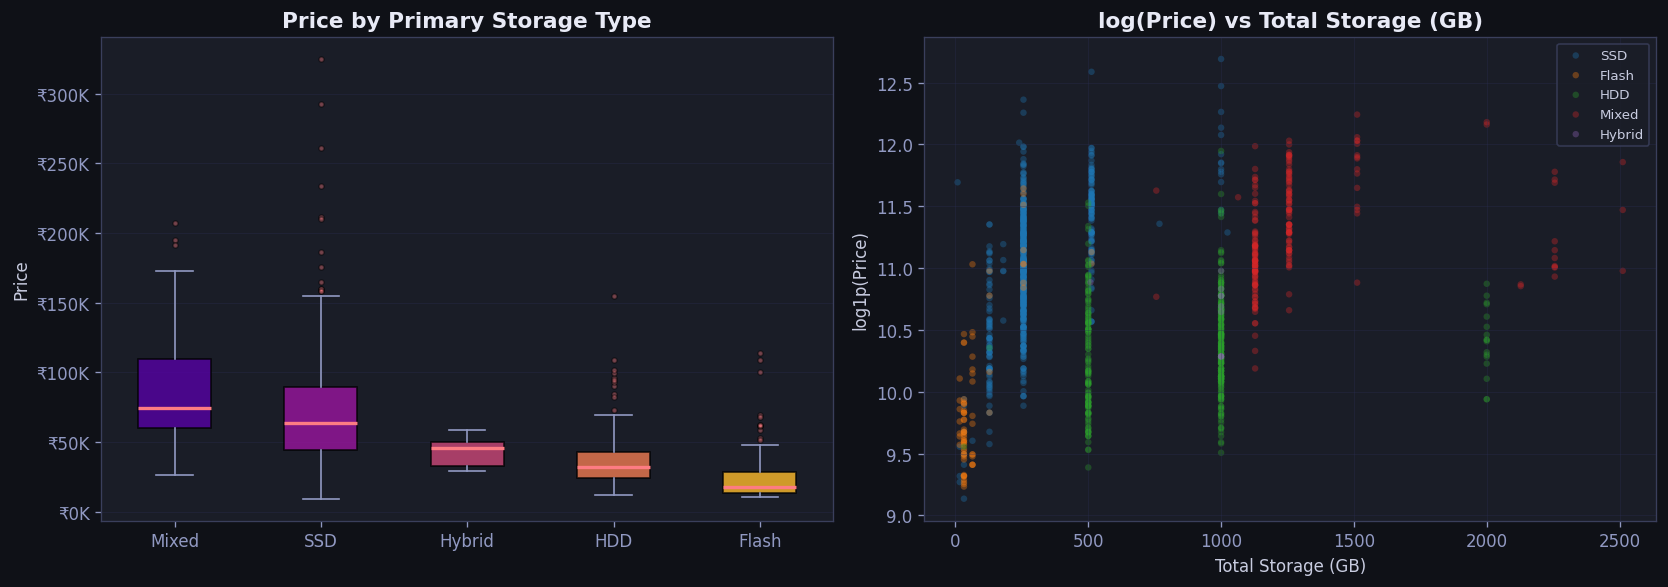

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price by primary storage type
ax = axes[0]
stor_order = (df.groupby("primary_storage_type")[TARGET].median()
                .sort_values(ascending=False).index)
data_stor = [df[df["primary_storage_type"]==s][TARGET].values for s in stor_order]
bp = ax.boxplot(data_stor, labels=stor_order, patch_artist=True,
                medianprops=dict(color=HIGHLIGHT, linewidth=2),
                whiskerprops=dict(color="#9199c2"),
                capprops=dict(color="#9199c2"),
                flierprops=dict(marker="o", markerfacecolor=HIGHLIGHT, markersize=3, alpha=0.4))
colors_st = plt.cm.plasma(np.linspace(0.15, 0.85, len(stor_order)))
for patch, color in zip(bp["boxes"], colors_st):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_inr))
ax.set_title("Price by Primary Storage Type")
ax.set_ylabel("Price")
ax.grid(axis="y", alpha=0.3)

# Scatter: total_storage_gb vs price
ax = axes[1]
stor_types = df["primary_storage_type"].unique()
palette = dict(zip(stor_types, plt.cm.plasma(np.linspace(0.1, 0.9, len(stor_types)))))
for stype in stor_types:
    mask = df["primary_storage_type"] == stype
    ax.scatter(df.loc[mask, "total_storage_gb"],
               np.log1p(df.loc[mask, TARGET]),
               alpha=0.35, s=15, label=stype, edgecolors="none")
ax.set_title("log(Price) vs Total Storage (GB)")
ax.set_xlabel("Total Storage (GB)")
ax.set_ylabel("log1p(Price)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Observations:**
- **SSD-primary** laptops command a significantly higher median price than HDD-primary — storage *type* matters more than raw storage size.
- **Mixed** (SSD + HDD combo) laptops sit between pure SSD and pure HDD in price.
- **Flash storage** (eMMC) is associated with cheaper devices (Chromebooks, Netbooks).
- Total storage GB alone is a weak predictor; storage *type* carries the real signal.

---
## 9. Price vs CPU

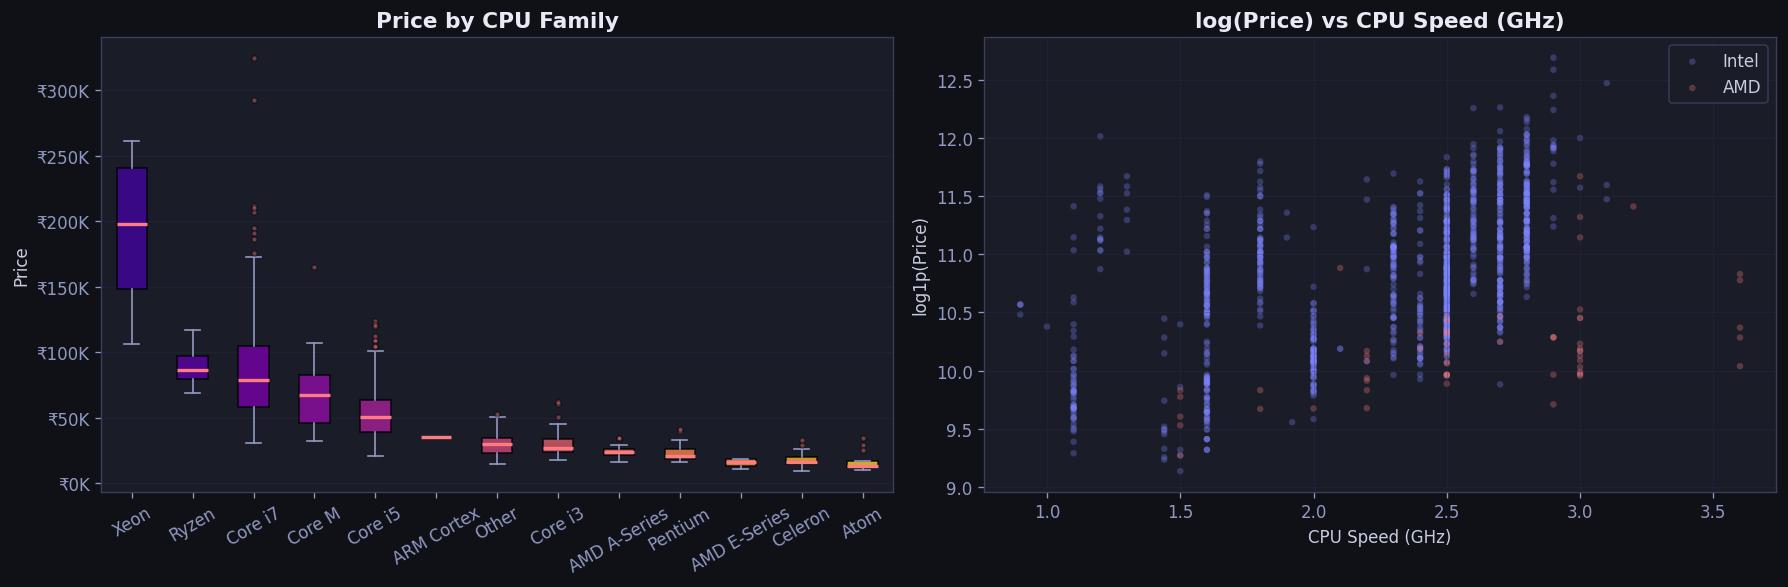

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Price by CPU family
ax = axes[0]
cpu_order = (df.groupby("cpu_family")[TARGET].median()
               .sort_values(ascending=False).index)
data_cpu  = [df[df["cpu_family"]==c][TARGET].values for c in cpu_order]
bp = ax.boxplot(data_cpu, labels=cpu_order, patch_artist=True,
                medianprops=dict(color=HIGHLIGHT, linewidth=2),
                whiskerprops=dict(color="#9199c2"),
                capprops=dict(color="#9199c2"),
                flierprops=dict(marker="o", markerfacecolor=HIGHLIGHT, markersize=3, alpha=0.4))
colors_cpu = plt.cm.plasma(np.linspace(0.1, 0.9, len(cpu_order)))
for patch, color in zip(bp["boxes"], colors_cpu):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.tick_params(axis="x", rotation=30)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_inr))
ax.set_title("Price by CPU Family")
ax.set_ylabel("Price")
ax.grid(axis="y", alpha=0.3)

# Price vs CPU speed
ax = axes[1]
for brand, color in zip(["Intel", "AMD"], [ACCENT, HIGHLIGHT]):
    mask = df["cpu_brand"] == brand
    ax.scatter(df.loc[mask, "cpu_speed_ghz"],
               np.log1p(df.loc[mask, TARGET]),
               alpha=0.3, s=15, label=brand, edgecolors="none", color=color)
ax.set_title("log(Price) vs CPU Speed (GHz)")
ax.set_xlabel("CPU Speed (GHz)")
ax.set_ylabel("log1p(Price)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Observations:**
- Clear price hierarchy: **Xeon > Core i7 > Core i5 > Core i3 > Core M > Pentium > Celeron > Atom**.
- CPU family is a strong ordinal price signal.
- CPU clock speed (GHz) alone shows a weak positive trend but is noisy — frequency is less important than tier.
- Rare CPU families (Xeon, ARM Cortex, Ryzen) are too sparse for reliable estimates.

---
## 10. Price vs GPU

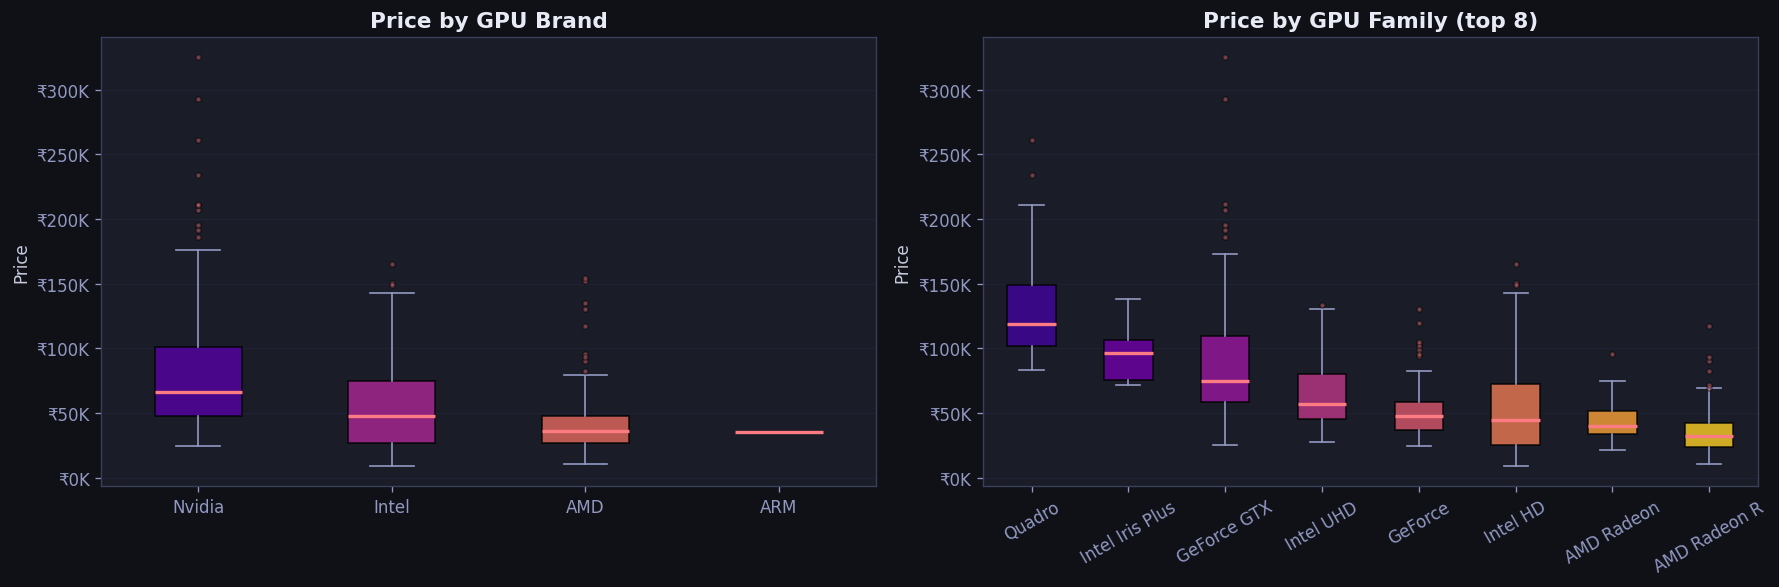

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Price by GPU brand
ax = axes[0]
gb_order = (df.groupby("gpu_brand")[TARGET].median()
              .sort_values(ascending=False).index)
data_gb  = [df[df["gpu_brand"]==g][TARGET].values for g in gb_order]
bp = ax.boxplot(data_gb, labels=gb_order, patch_artist=True,
                medianprops=dict(color=HIGHLIGHT, linewidth=2),
                whiskerprops=dict(color="#9199c2"),
                capprops=dict(color="#9199c2"),
                flierprops=dict(marker="o", markerfacecolor=HIGHLIGHT, markersize=3, alpha=0.4))
col_gb = plt.cm.plasma(np.linspace(0.15, 0.85, len(gb_order)))
for patch, c in zip(bp["boxes"], col_gb):
    patch.set_facecolor(c)
    patch.set_alpha(0.8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_inr))
ax.set_title("Price by GPU Brand")
ax.set_ylabel("Price")
ax.grid(axis="y", alpha=0.3)

# Price by GPU family (top families by count)
ax = axes[1]
top_gpu_fam = df["gpu_family"].value_counts().head(8).index
df_top_gpu  = df[df["gpu_family"].isin(top_gpu_fam)]
gf_order = (df_top_gpu.groupby("gpu_family")[TARGET].median()
                       .sort_values(ascending=False).index)
data_gf  = [df_top_gpu[df_top_gpu["gpu_family"]==g][TARGET].values for g in gf_order]
bp2 = ax.boxplot(data_gf, labels=gf_order, patch_artist=True,
                 medianprops=dict(color=HIGHLIGHT, linewidth=2),
                 whiskerprops=dict(color="#9199c2"),
                 capprops=dict(color="#9199c2"),
                 flierprops=dict(marker="o", markerfacecolor=HIGHLIGHT, markersize=3, alpha=0.4))
col_gf = plt.cm.plasma(np.linspace(0.1, 0.9, len(gf_order)))
for patch, c in zip(bp2["boxes"], col_gf):
    patch.set_facecolor(c)
    patch.set_alpha(0.8)
ax.tick_params(axis="x", rotation=30)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_inr))
ax.set_title("Price by GPU Family (top 8)")
ax.set_ylabel("Price")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Observations:**
- **Nvidia** GPU laptops command significantly higher prices than **AMD** and **Intel** (integrated).
- **GeForce GTX** family has the highest median; **Intel HD** (integrated) sits at the bottom.
- GPU brand/family is a strong price discriminator — the presence of a dedicated GPU (Nvidia/AMD) vs integrated (Intel) is a key feature.
- Quadro GPUs appear in expensive workstations.

---
## 11. Price vs Screen Size

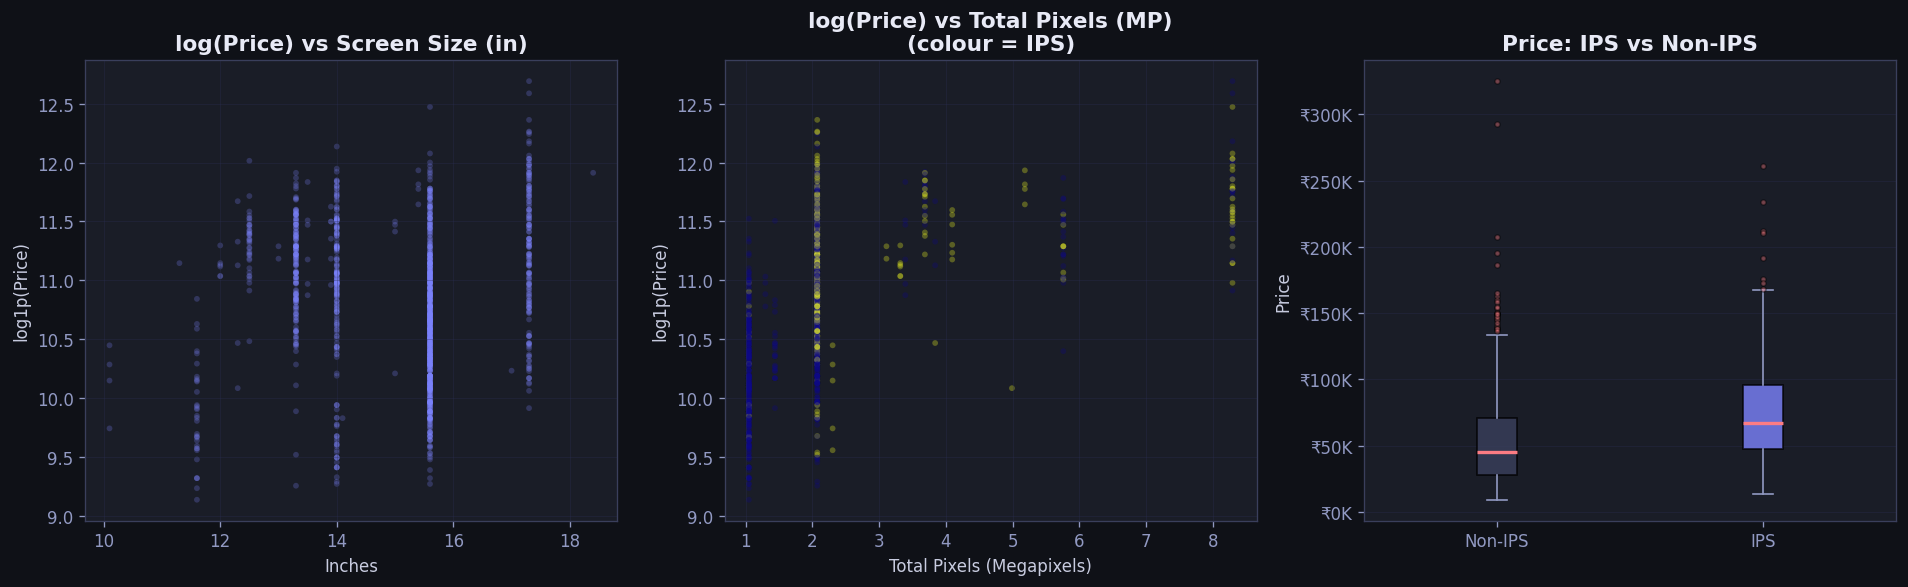

Median price — IPS: ₹67,133  |  Non-IPS: ₹45,168
Median price — Touchscreen: ₹74,539  |  Non-touch: ₹48,964


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Scatter: screen inches vs price
ax = axes[0]
ax.scatter(df["Inches"], np.log1p(df[TARGET]), alpha=0.25, s=12,
           color=ACCENT, edgecolors="none")
ax.set_title("log(Price) vs Screen Size (in)")
ax.set_xlabel("Inches")
ax.set_ylabel("log1p(Price)")
ax.grid(alpha=0.3)

# Scatter: total pixels vs price
ax = axes[1]
ax.scatter(df["total_pixels"] / 1e6, np.log1p(df[TARGET]),
           c=df["is_ips"], cmap="plasma", alpha=0.3, s=12, edgecolors="none")
ax.set_title("log(Price) vs Total Pixels (MP)\n(colour = IPS)")
ax.set_xlabel("Total Pixels (Megapixels)")
ax.set_ylabel("log1p(Price)")
ax.grid(alpha=0.3)

# IPS vs non-IPS price
ax = axes[2]
labels = ["Non-IPS", "IPS"]
data_ips = [df[df["is_ips"]==0][TARGET].values,
            df[df["is_ips"]==1][TARGET].values]
bp = ax.boxplot(data_ips, labels=labels, patch_artist=True,
                medianprops=dict(color=HIGHLIGHT, linewidth=2),
                whiskerprops=dict(color="#9199c2"),
                capprops=dict(color="#9199c2"),
                flierprops=dict(marker="o", markerfacecolor=HIGHLIGHT, markersize=3, alpha=0.4))
for patch, color in zip(bp["boxes"], ["#3a3f5c", ACCENT]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_inr))
ax.set_title("Price: IPS vs Non-IPS")
ax.set_ylabel("Price")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

ips_med = df.groupby("is_ips")[TARGET].median()
touch_med = df.groupby("is_touchscreen")[TARGET].median()
print(f"Median price — IPS: ₹{ips_med[1]:,.0f}  |  Non-IPS: ₹{ips_med[0]:,.0f}")
print(f"Median price — Touchscreen: ₹{touch_med[1]:,.0f}  |  Non-touch: ₹{touch_med[0]:,.0f}")

**Observations:**
- Screen size (Inches) has a **weak and noisy** correlation with price — the same 15.6" form factor spans budget to premium.
- **Higher pixel count** (4K/Retina displays) is associated with higher prices.
- **IPS panels** have notably higher median prices — IPS is a meaningful binary feature.
- **Touchscreen** is also associated with a premium, though the effect is smaller.

---
## 12. Price vs Weight

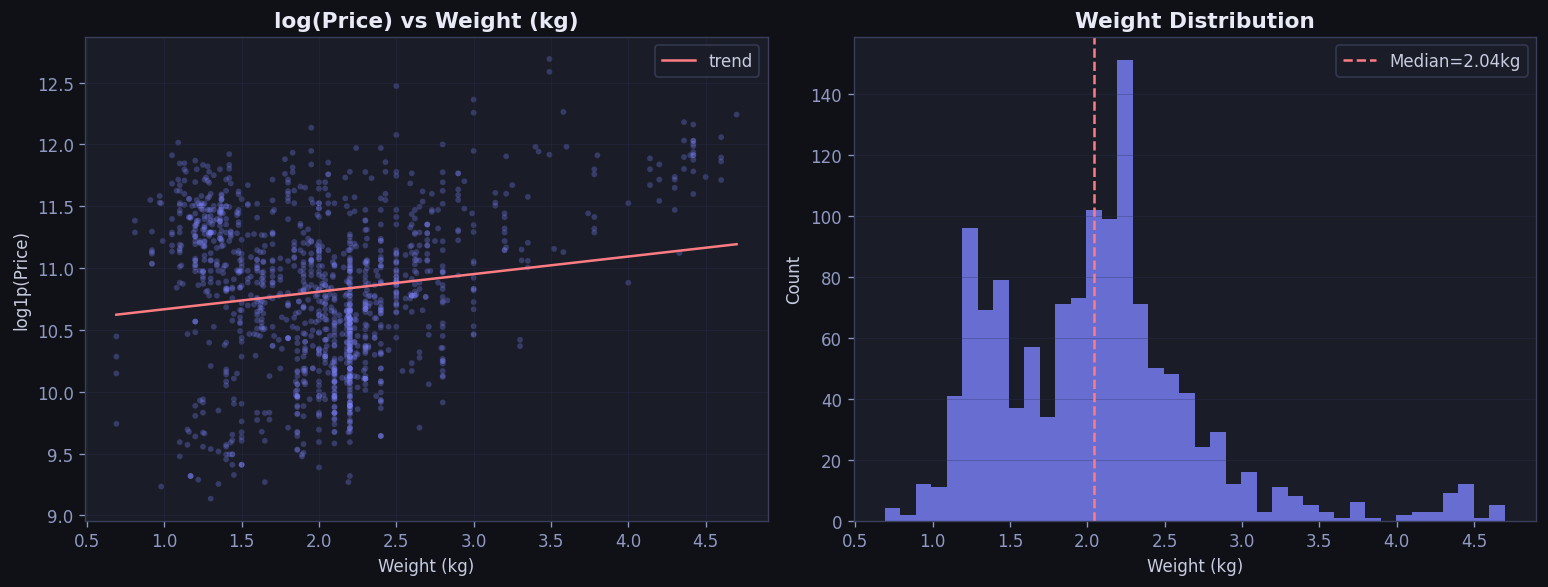

Pearson correlation (weight_kg vs Price): 0.2104


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(df["weight_kg"], np.log1p(df[TARGET]),
           alpha=0.3, s=12, color=ACCENT, edgecolors="none")
# Trend line
z = np.polyfit(df["weight_kg"], np.log1p(df[TARGET]), 1)
p = np.poly1d(z)
xr = np.linspace(df["weight_kg"].min(), df["weight_kg"].max(), 100)
ax.plot(xr, p(xr), color=HIGHLIGHT, linewidth=1.5, label="trend")
ax.set_title("log(Price) vs Weight (kg)")
ax.set_xlabel("Weight (kg)")
ax.set_ylabel("log1p(Price)")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.hist(df["weight_kg"], bins=40, color=ACCENT, edgecolor="none", alpha=0.8)
ax.set_title("Weight Distribution")
ax.set_xlabel("Weight (kg)")
ax.set_ylabel("Count")
ax.grid(axis="y", alpha=0.3)
ax.axvline(df["weight_kg"].median(), color=HIGHLIGHT, linewidth=1.5,
           linestyle="--", label=f"Median={df['weight_kg'].median():.2f}kg")
ax.legend()

plt.tight_layout()
plt.show()

corr = df["weight_kg"].corr(df[TARGET])
print(f"Pearson correlation (weight_kg vs Price): {corr:.4f}")

**Observations:**
- Weight shows a **slight negative correlation** with price — lighter laptops tend to be premium (ultrabooks, MacBooks).
- Very heavy laptops (>3.5 kg) are mostly gaming/workstation machines — high price, high weight.
- Weight is useful but not the dominant signal — it interacts with laptop type.

---
## 13. Correlation Analysis

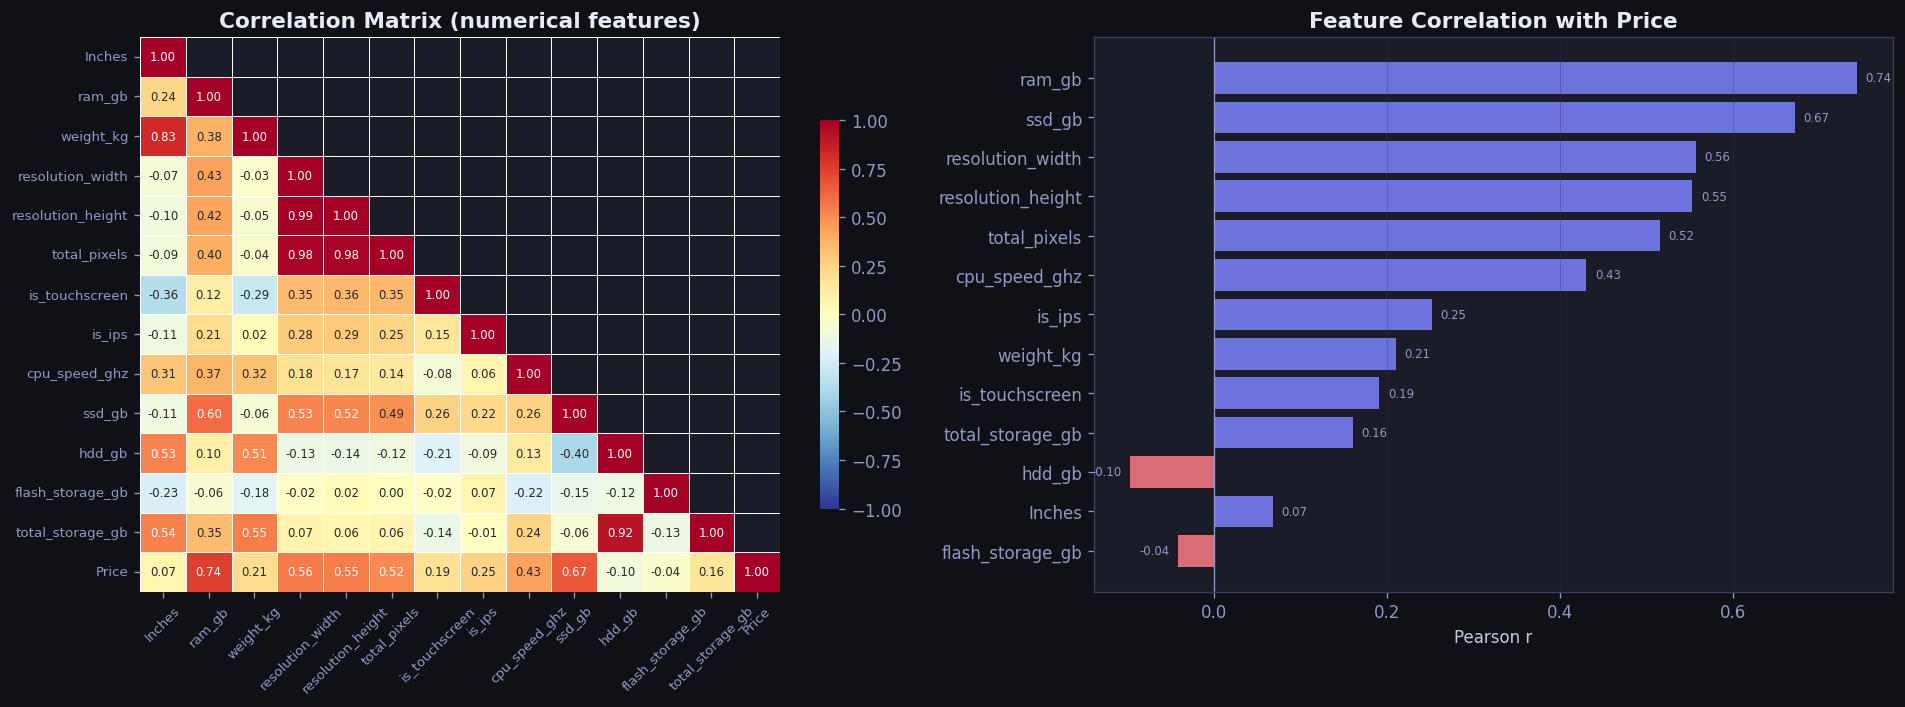

In [14]:
num_features = [
    "Inches", "ram_gb", "weight_kg",
    "resolution_width", "resolution_height", "total_pixels",
    "is_touchscreen", "is_ips",
    "cpu_speed_ghz",
    "ssd_gb", "hdd_gb", "flash_storage_gb", "total_storage_gb",
    "Price"
]

corr_matrix = df[num_features].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full heatmap
ax = axes[0]
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="RdYlBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.3, ax=ax,
            annot_kws={"size": 7},
            cbar_kws={"shrink": 0.7})
ax.set_title("Correlation Matrix (numerical features)")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", labelsize=8)

# Price correlations bar
ax = axes[1]
price_corr = (corr_matrix["Price"]
              .drop("Price")
              .sort_values(key=abs, ascending=False))
colors_bar = [ACCENT if v >= 0 else HIGHLIGHT for v in price_corr.values]
bars = ax.barh(price_corr.index[::-1], price_corr.values[::-1],
               color=colors_bar[::-1], edgecolor="none", alpha=0.85)
ax.axvline(0, color="#9199c2", linewidth=0.8)
ax.set_title("Feature Correlation with Price")
ax.set_xlabel("Pearson r")
ax.grid(axis="x", alpha=0.3)
for bar, val in zip(bars, price_corr.values[::-1]):
    ax.text(val + (0.01 if val >= 0 else -0.01),
            bar.get_y() + bar.get_height()/2,
            f"{val:.2f}", va="center", fontsize=7,
            color="#9199c2", ha=("left" if val >= 0 else "right"))

plt.tight_layout()
plt.show()

**Observations:**
- **`ram_gb`** has the strongest positive correlation with Price (Pearson r ≈ 0.75).
- **`total_pixels`** / `resolution_width` / `resolution_height` show moderate positive correlation.
- **`is_ips`** has a meaningful positive correlation.
- **`hdd_gb`** shows a slight negative correlation — HDD presence signals budget laptops.
- **`ssd_gb`** has a positive correlation, confirming SSD = premium segment.
- **`Inches`** and **`weight_kg`** are weak predictors individually.
- **Note:** `resolution_width`, `resolution_height`, and `total_pixels` are nearly perfectly collinear — only one should be retained for linear models.

---
## 14. Summary of Key Findings

In [15]:
print("=" * 60)
print("  EDA SUMMARY")
print("=" * 60)
print(f"  Dataset      : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Target       : Price (INR), skew = {df['Price'].skew():.2f}")
print(f"  Price range  : ₹{df['Price'].min():,.0f} – ₹{df['Price'].max():,.0f}")
print(f"  Missing vals : 0")
print(f"  Duplicates   : 0")
print()
print("  TOP PRICE DRIVERS (by analysis)")
print("  1. ram_gb           — strongest numerical predictor")
print("  2. cpu_family       — strong ordinal signal (Xeon > i7 > i5…)")
print("  3. gpu_brand/family — Nvidia > AMD > Intel integrated")
print("  4. Company          — brand premium (Razer, LG, Apple > budget)")
print("  5. primary_storage  — SSD > Mixed > HDD > Flash")
print("  6. total_pixels     — higher resolution = higher price")
print("  7. TypeName         — Workstation > Gaming > Ultrabook > Notebook")
print("  8. is_ips           — IPS panel adds premium")
print()
print("  DECISIONS NEEDED BEFORE MODELLING")
print("  A. Log-transform Price? (recommended — reduces skew)")
print("  B. Group rare RAM tiers? (2GB/6GB/12GB/24GB/64GB — very sparse)")
print("  C. Group rare Companies? (Huawei n=2, Chuwi n=3, etc.)")
print("  D. Handle multicollinearity? (width/height/total_pixels)")
print("  E. Encode strategy? (OHE vs ordinal vs target for CPU/GPU family)")
print("  F. Keep the Samsung/ARM Cortex row? (unique device, 1 row each)")
print("=" * 60)

  EDA SUMMARY
  Dataset      : 1,303 rows × 29 columns
  Target       : Price (INR), skew = 1.52
  Price range  : ₹9,271 – ₹324,955
  Missing vals : 0
  Duplicates   : 0

  TOP PRICE DRIVERS (by analysis)
  1. ram_gb           — strongest numerical predictor
  2. cpu_family       — strong ordinal signal (Xeon > i7 > i5…)
  3. gpu_brand/family — Nvidia > AMD > Intel integrated
  4. Company          — brand premium (Razer, LG, Apple > budget)
  5. primary_storage  — SSD > Mixed > HDD > Flash
  6. total_pixels     — higher resolution = higher price
  7. TypeName         — Workstation > Gaming > Ultrabook > Notebook
  8. is_ips           — IPS panel adds premium

  DECISIONS NEEDED BEFORE MODELLING
  A. Log-transform Price? (recommended — reduces skew)
  B. Group rare RAM tiers? (2GB/6GB/12GB/24GB/64GB — very sparse)
  C. Group rare Companies? (Huawei n=2, Chuwi n=3, etc.)
  D. Handle multicollinearity? (width/height/total_pixels)
  E. Encode strategy? (OHE vs ordinal vs target for CPU/GPU

---
*End of EDA Notebook — `01_eda.ipynb`*